# kiểm tra các chỉ số quan trọng của 1 database
### 1. Tỷ lệ dữ liệu bị thiếu (% Missing Values)
* **Tại sao:** Hầu hết các mô hình toán học không thể tính toán với các ô trống (NaN/Null). Bạn cần quyết định nên điền khuyết (Imputation) hay xóa bỏ.
* **Chỉ số cần quan tâm:** Tỷ lệ phần trăm dòng bị thiếu của từng cột.
  * Nếu thiếu `< 5%`: Thường có thể xóa dòng.
  * Nếu thiếu `5% - 40%`: Điền khuyết bằng Mean, Median hoặc dùng mô hình dự đoán.
  * Nếu thiếu `> 40-50%`: Thường cân nhắc xóa luôn cột đó vì dữ liệu giả lập quá nhiều sẽ làm sai lệch thực tế.

### 2. Chỉ số phát hiện Điểm ngoại lai (Outliers)
* **Tại sao:** Các mô hình hồi quy (đặc biệt là Linear Regression, Ridge, Lasso) cực kỳ nhạy cảm với điểm ngoại lai. Một vài điểm dữ liệu quá lớn hoặc quá nhỏ có thể bẻ cong hoàn toàn đường dự đoán.
* **Chỉ số cần quan tâm:**
  * **Z-score:** Nếu một điểm dữ liệu có $|Z-score| > 3$, nó thường bị coi là ngoại lai.
  * **IQR (Interquartile Range):** Những giá trị nằm ngoài khoảng $[Q1 - 1.5 \times IQR, Q3 + 1.5 \times IQR]$ cần được xem xét cắt xén (clipping) hoặc loại bỏ.

### 3. Hệ số tương quan với biến mục tiêu (Feature-Target Correlation)
* **Tại sao:** Trước khi đưa một biến vào mô hình, bạn phải biết nó có "thực sự liên quan" đến cái bạn muốn dự đoán (ví dụ: Yield/Sản lượng) hay không.
* **Chỉ số cần quan tâm:** Hệ số Pearson ($r$) hoặc Spearman ($\rho$).
  * Giá trị chạy từ $-1$ đến $1$.
  * Nếu tương quan sát $0$ (ví dụ: $0.01$), biến đó gần như vô dụng trong việc dự đoán mục tiêu.

### 4. Hệ số phóng đại phương sai (VIF) & Ma trận tương quan
* **Tại sao:** Để phát hiện Đa cộng tuyến (Multicollinearity). Nếu các biến đầu vào tự giải thích cho nhau quá tốt, mô hình sẽ bị nhiễu và mất tính ổn định.
* **Chỉ số cần quan tâm:**
  * **Hệ số tương quan giữa 2 biến độc lập:** Nếu $> 0.8$ là có dấu hiệu báo động.
  * **VIF (Variance Inflation Factor):** Nếu $VIF > 5$ (hoặc $> 10$), biến đó đang bị đa cộng tuyến nặng và cần xem xét dùng PCA, loại bỏ, hoặc dùng mô hình Tree-based.

### 5. Độ lệch phân phối (Skewness)
* **Tại sao:** Nhiều thuật toán hồi quy giả định rằng các biến số (đặc biệt là biến mục tiêu) tuân theo phân phối chuẩn (hình quả chuông).
* **Chỉ số cần quan tâm:** Skewness.
  * Phân phối chuẩn có $Skewness \approx 0$.
  * Nếu $Skewness > 1$ (lệch phải) hoặc $< -1$ (lệch trái), bạn thường phải biến đổi dữ liệu (ví dụ: lấy Logarit, căn bậc 2, hoặc Box-Cox) để kéo nó về gần chuẩn hơn.

### 6. Phương sai / Độ lệch chuẩn (Variance / Standard Deviation)
* **Tại sao:** Phương sai thể hiện sự biến động của dữ liệu. Nếu một cột không có sự biến động, nó không mang lại thông tin gì.
* **Chỉ số cần quan tâm:**
  * **Standard Deviation ($std$):** Nếu $std = 0$ (tức là tất cả các dòng đều có chung 1 giá trị), cột đó vô nghĩa, hãy xóa ngay lập tức (Zero Variance Threshold).
  * **Chênh lệch thang đo:** Nếu cột A có $std = 1000$ và cột B có $std = 0.1$, bạn bắt buộc phải dùng kỹ thuật Scaling (như StandardScaler hoặc MinMaxScaler) trước khi chạy mô hình, nếu không mô hình sẽ bị thiên lệch hoàn toàn vào cột A.

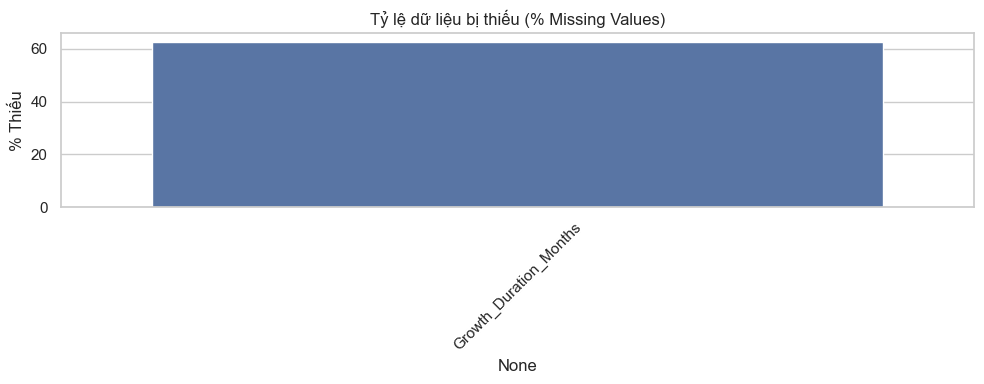

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. TẢI DỮ LIỆU VÀ XÁC ĐỊNH BIẾN
df = pd.read_csv('Agri_Data_Cleaned.csv') # Thay tên file ở đây
target_col = 'Yield' # Thay bằng biến mục tiêu (Ví dụ: 'Yield')

# Tách cột số và cột chữ (categorical)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

if target_col in numeric_cols:
    numeric_predictors = [c for c in numeric_cols if c != target_col]
else:
    numeric_predictors = numeric_cols

sns.set_theme(style="whitegrid")

# ==========================================
# CHỈ SỐ 1: TỶ LỆ DỮ LIỆU BỊ THIẾU (MISSING)
# ==========================================
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 4))
if not missing_percent.empty:
    sns.barplot(x=missing_percent.index, y=missing_percent.values)
    plt.title('Tỷ lệ dữ liệu bị thiếu (% Missing Values)')
    plt.ylabel('% Thiếu')
    plt.xticks(rotation=45)
else:
    plt.text(0.5, 0.5, 'Không có dữ liệu bị thiếu (0% Missing)', ha='center', va='center', fontsize=15)
    plt.axis('off')
plt.tight_layout()
plt.show()


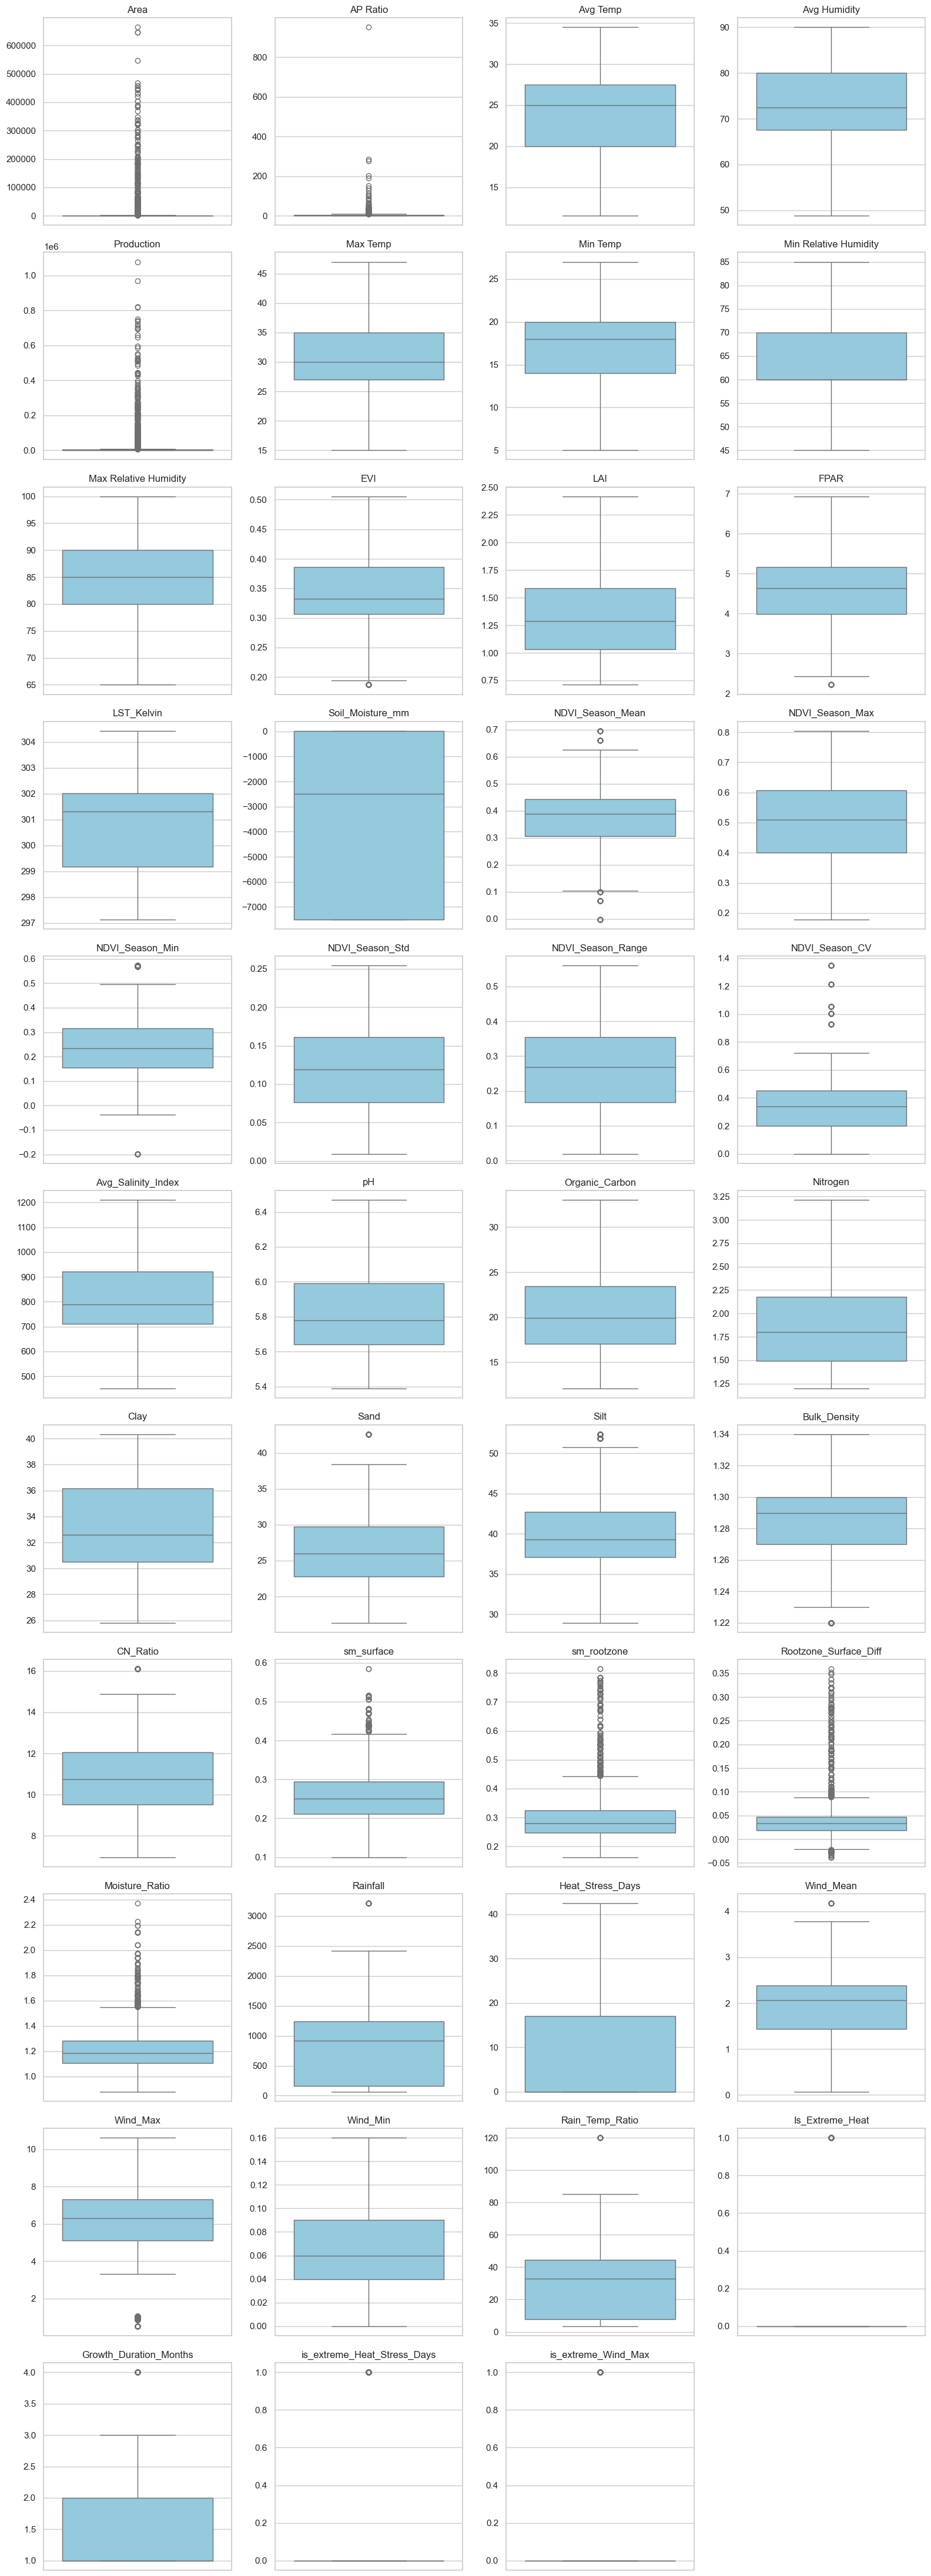

In [7]:
import math

# ==========================================
# CHỈ SỐ 2: NGOẠI LAI (OUTLIERS) VỚI BOXPLOT TẤT CẢ BIẾN
# ==========================================
# Lấy danh sách toàn bộ các cột số
all_num_cols = numeric_predictors

# Tính toán layout (Lưới biểu đồ)
n_features = len(all_num_cols)
cols = 4  # Bạn có thể đổi số này (ví dụ: 4 hoặc 5 biểu đồ trên 1 hàng)
rows = math.ceil(n_features / cols) # Tự động tính số hàng cần thiết

# Khởi tạo khung vẽ, chiều cao tự động co giãn theo số hàng
plt.figure(figsize=(16, rows * 4))

# Vẽ boxplot cho từng biến
for i, col in enumerate(all_num_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'{col}', fontsize=12)
    plt.ylabel('') # Tắt chữ ở trục Y cho đỡ rối

plt.tight_layout()
plt.show()


In [8]:
# ==========================================
# CHỈ SỐ 3: TƯƠNG QUAN VỚI BIẾN MỤC TIÊU (HIỂN THỊ TẤT CẢ)
# ==========================================
if target_col in numeric_cols:
    # Tính toán tương quan cho toàn bộ các biến số
    corr_with_target = df[numeric_cols].corr()[target_col].drop(target_col).sort_values(ascending=False)
    
    # Tự động tính chiều cao biểu đồ: Mỗi biến sẽ có không gian 0.4 inch, tối thiểu là 8 inch
    dynamic_height = max(8, len(corr_with_target) * 0.4)
    
    # Mở rộng khung vẽ theo chiều cao tự động
    plt.figure(figsize=(12, dynamic_height))
    
    # Vẽ biểu đồ thanh
    ax = sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')
    
    plt.title(f'Tương quan Pearson với biến mục tiêu ({target_col})', fontsize=16, pad=20)
    plt.xlabel('Hệ số tương quan Pearson (Từ -1 đến 1)', fontsize=12)
    plt.ylabel('Các biến độc lập (Features)', fontsize=12)
    
    # Thêm giá trị số cụ thể lên cuối mỗi thanh biểu đồ
    for i, val in enumerate(corr_with_target.values):
        # Căn lề số: nếu số dương thì để bên phải thanh, số âm thì để bên trái thanh
        x_offset = 0.01 if val >= 0 else -0.01
        ha_align = 'left' if val >= 0 else 'right'
        plt.text(val + x_offset, i, f'{val:.2f}', va='center', ha=ha_align, fontsize=10, color='black')
        
    plt.tight_layout()
    plt.show()

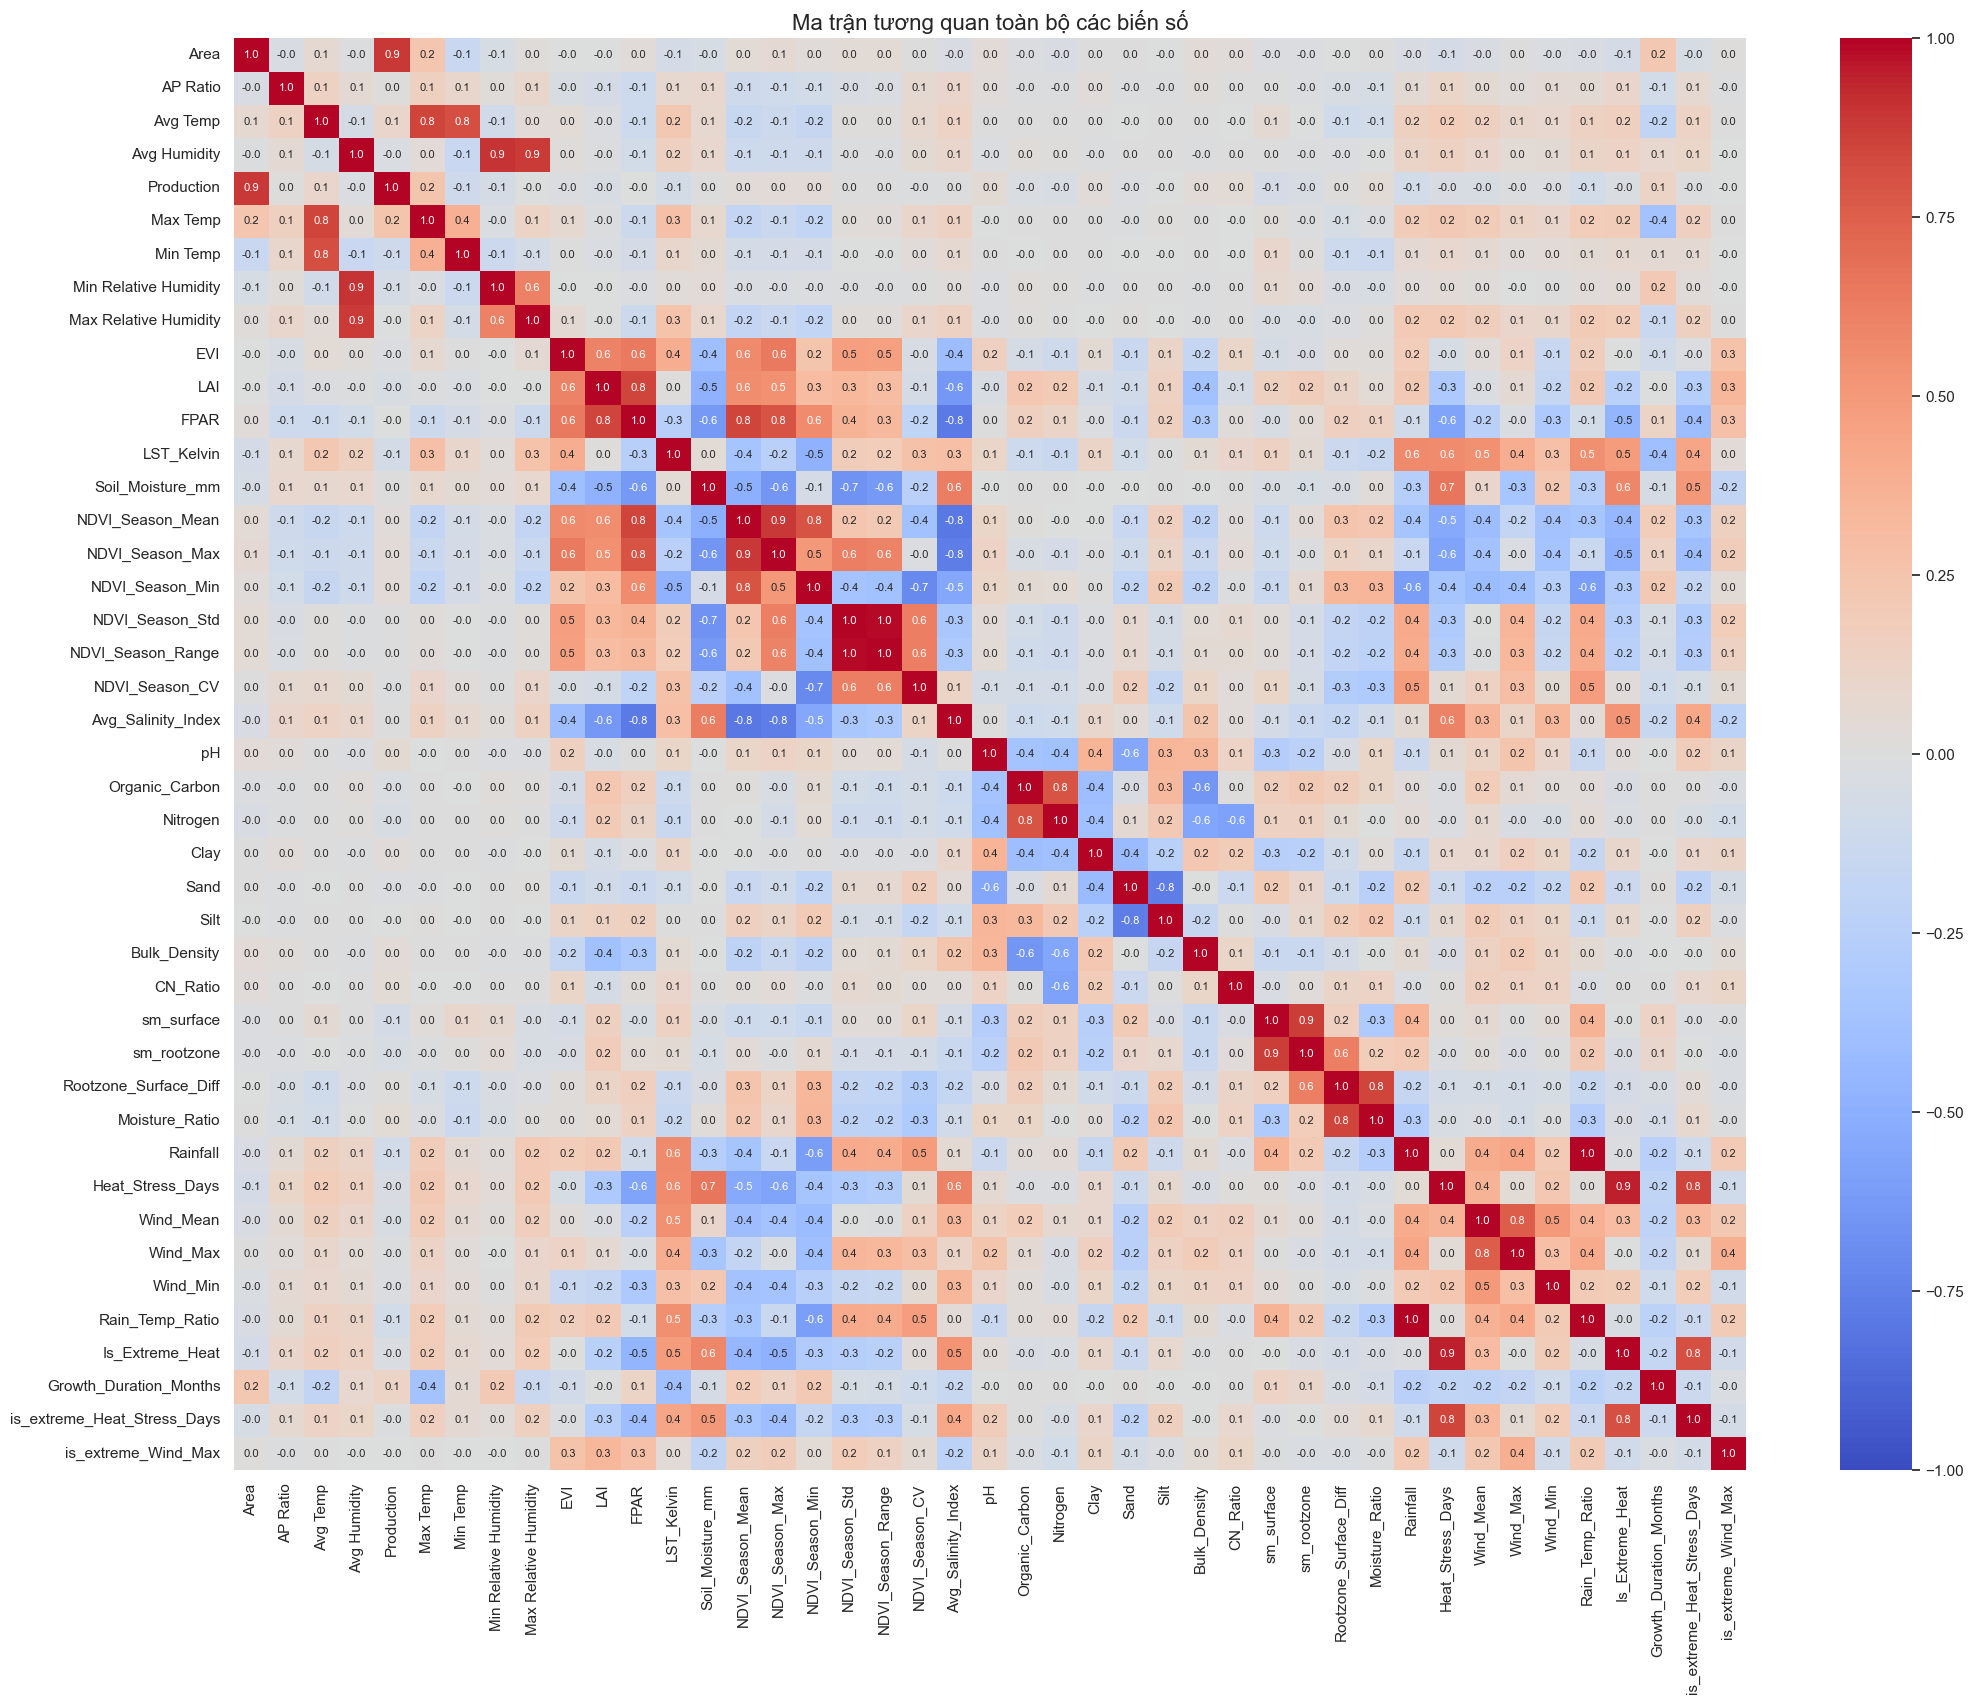


--- ĐANG TÍNH TOÁN VIF CHO TOÀN BỘ CÁC CỘT (VUI LÒNG ĐỢI)... ---


c:\Users\AKANEMO\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\AKANEMO\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\AKANEMO\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\AKANEMO\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\AKANEMO\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero e


--- BÁO CÁO VIF ĐẦY ĐỦ (Sắp xếp theo mức độ đa cộng tuyến) ---
                        Feature           VIF
0                      Avg Temp           inf
1                      Max Temp           inf
2                  Avg Humidity           inf
3         Max Relative Humidity           inf
4         Min Relative Humidity           inf
5                      Min Temp           inf
6               NDVI_Season_Min           inf
7             NDVI_Season_Range           inf
8               NDVI_Season_Max           inf
9                   sm_rootzone  3.586440e+07
10                   sm_surface  2.844472e+07
11        Rootzone_Surface_Diff  1.091015e+06
12                   LST_Kelvin  2.219153e+05
13                         Silt  3.864376e+04
14                         Clay  2.630744e+04
15                         Sand  1.701848e+04
16                     Rainfall  1.628552e+04
17              Rain_Temp_Ratio  1.617980e+04
18                 Bulk_Density  7.553740e+03
19              

C:\Users\AKANEMO\AppData\Local\Temp\ipykernel_23388\313055646.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='VIF', y='Feature', data=top_vif, palette='Reds_r')


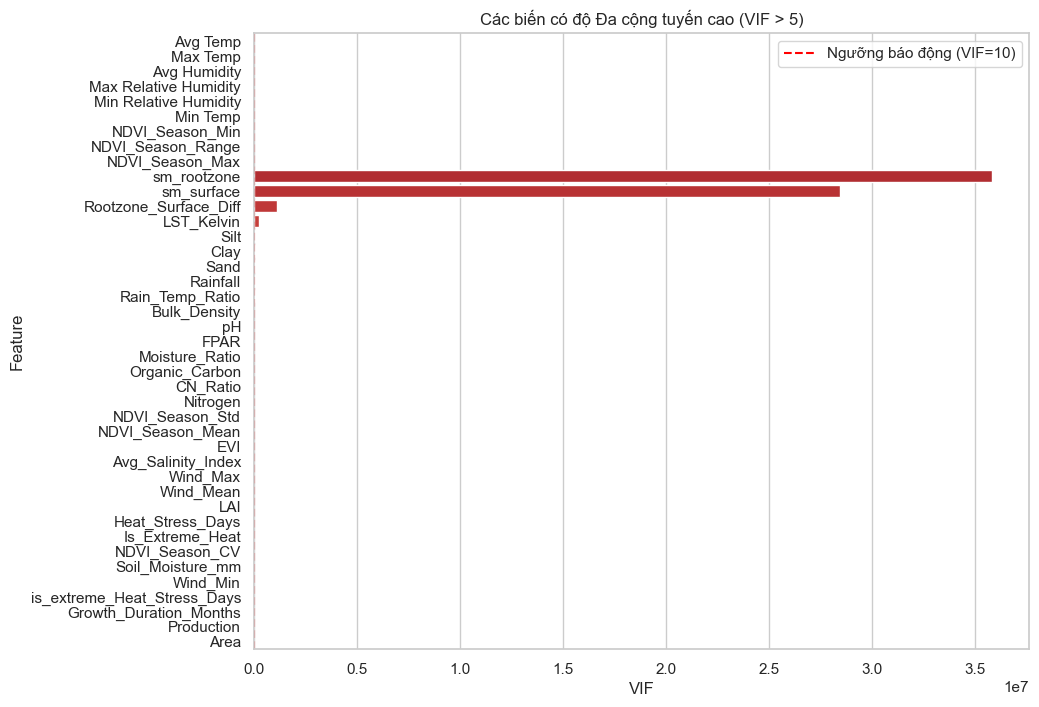

In [9]:
# ==========================================
# CHỈ SỐ 4: ĐA CỘNG TUYẾN & VIF (TOÀN BỘ CỘT)
# ==========================================

# 4.1. Ma trận tương quan (Heatmap) cho tất cả các biến
all_num_features = numeric_predictors

# Tự động tính kích thước: mỗi biến chiếm khoảng 0.5 inch để đảm bảo đọc được số
plt_size = max(10, len(all_num_features) * 0.5)
plt.figure(figsize=(plt_size, plt_size * 0.8))

corr_matrix = df[all_num_features].corr()

# Vẽ Heatmap
sns.heatmap(corr_matrix, 
            annot=True,          # Hiện số
            fmt=".1f",           # Rút gọn còn 1 chữ số thập phân cho đỡ rối
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            annot_kws={"size": 8}) # Chữ trong ô nhỏ lại một chút

plt.title('Ma trận tương quan toàn bộ các biến số', fontsize=16)
plt.tight_layout()
plt.show()

# 4.2. Tính toán VIF cho toàn bộ các biến
print("\n--- ĐANG TÍNH TOÁN VIF CHO TOÀN BỘ CÁC CỘT (VUI LÒNG ĐỢI)... ---")

# Loại bỏ các cột có phương sai bằng 0 (như cột 'Year' nếu chỉ có 1 giá trị) vì VIF không tính được
vif_df_input = df[all_num_features].dropna()
constant_cols = [col for col in vif_df_input.columns if vif_df_input[col].nunique() <= 1]
vif_features = [col for col in all_num_features if col not in constant_cols]

if len(constant_cols) > 0:
    print(f"Lưu ý: Đã loại bỏ các cột {constant_cols} khỏi VIF vì chúng không thay đổi giá trị.")

vif_data = pd.DataFrame()
vif_data["Feature"] = vif_features
vif_data["VIF"] = [variance_inflation_factor(vif_df_input[vif_features].values, i) 
                   for i in range(len(vif_features))]

# Sắp xếp VIF từ cao đến thấp để dễ theo dõi
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("\n--- BÁO CÁO VIF ĐẦY ĐỦ (Sắp xếp theo mức độ đa cộng tuyến) ---")
# Hiển thị toàn bộ bảng VIF
with pd.option_context('display.max_rows', None): 
    print(vif_data)

# Trực quan hóa VIF bằng biểu đồ thanh (chỉ lấy những biến có VIF > 5 để xử lý)
plt.figure(figsize=(10, 8))
top_vif = vif_data[vif_data['VIF'] > 5]
if not top_vif.empty:
    sns.barplot(x='VIF', y='Feature', data=top_vif, palette='Reds_r')
    plt.axvline(x=10, color='red', linestyle='--', label='Ngưỡng báo động (VIF=10)')
    plt.title('Các biến có độ Đa cộng tuyến cao (VIF > 5)')
    plt.legend()
    plt.show()
else:
    print("Tuyệt vời! Không có biến nào có VIF > 5.")


--- BÁO CÁO PHÂN PHỐI & PHƯƠNG SAI ĐẦY ĐỦ (Tất cả cột số) ---
                            Kiểu dữ liệu  Độ lệch chuẩn (Std Dev)  \
AP Ratio                         float64                17.983998   
Area                               int64             44187.096250   
Production                         int64             68753.150416   
is_extreme_Wind_Max                int64                 0.149850   
Rootzone_Surface_Diff            float64                 0.042653   
sm_rootzone                      float64                 0.085292   
is_extreme_Heat_Stress_Days        int64                 0.379572   
NDVI_Season_CV                   float64                 0.197557   
Moisture_Ratio                   float64                 0.160595   
Growth_Duration_Months           float64                 0.801730   
Is_Extreme_Heat                    int64                 0.429768   
Heat_Stress_Days                 float64                17.015995   
Nitrogen                         float64

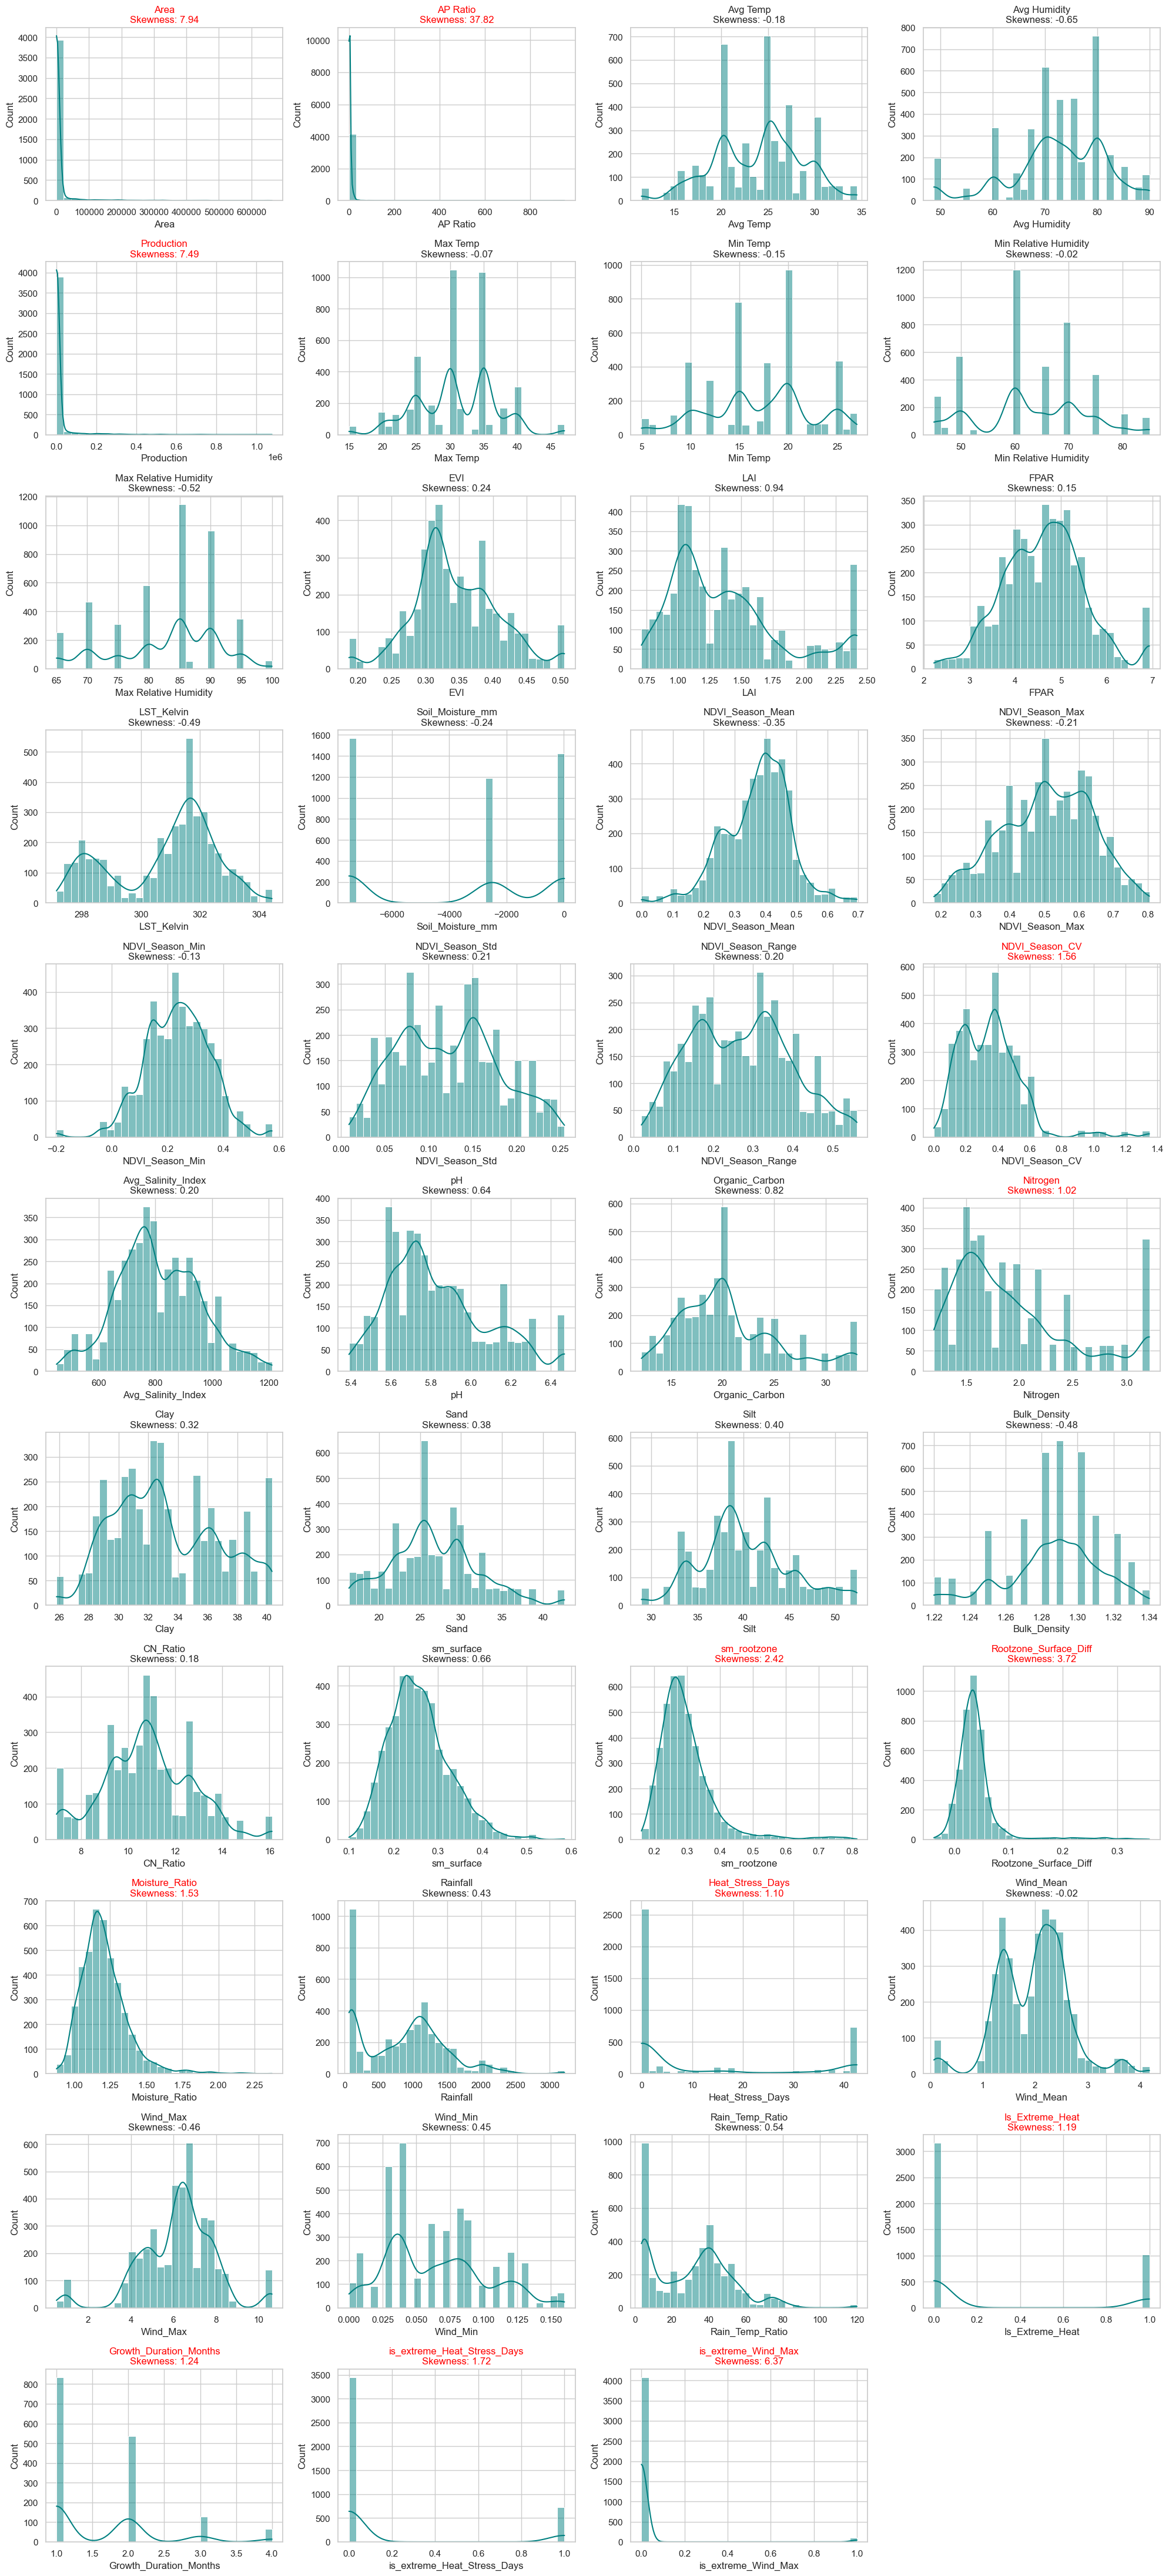


--- PHÂN TÍCH CHI TIẾT BIẾN PHÂN LOẠI (CATEGORICAL) ---


C:\Users\AKANEMO\AppData\Local\Temp\ipykernel_23388\276573889.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_n.values, y=top_n.index, palette='viridis')
C:\Users\AKANEMO\AppData\Local\Temp\ipykernel_23388\276573889.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_n.values, y=top_n.index, palette='viridis')
C:\Users\AKANEMO\AppData\Local\Temp\ipykernel_23388\276573889.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_n.values, y=top_n.index, palette='viridis')
C:\Users\AKANEMO\AppData\Local\Temp\ipykernel_23388\

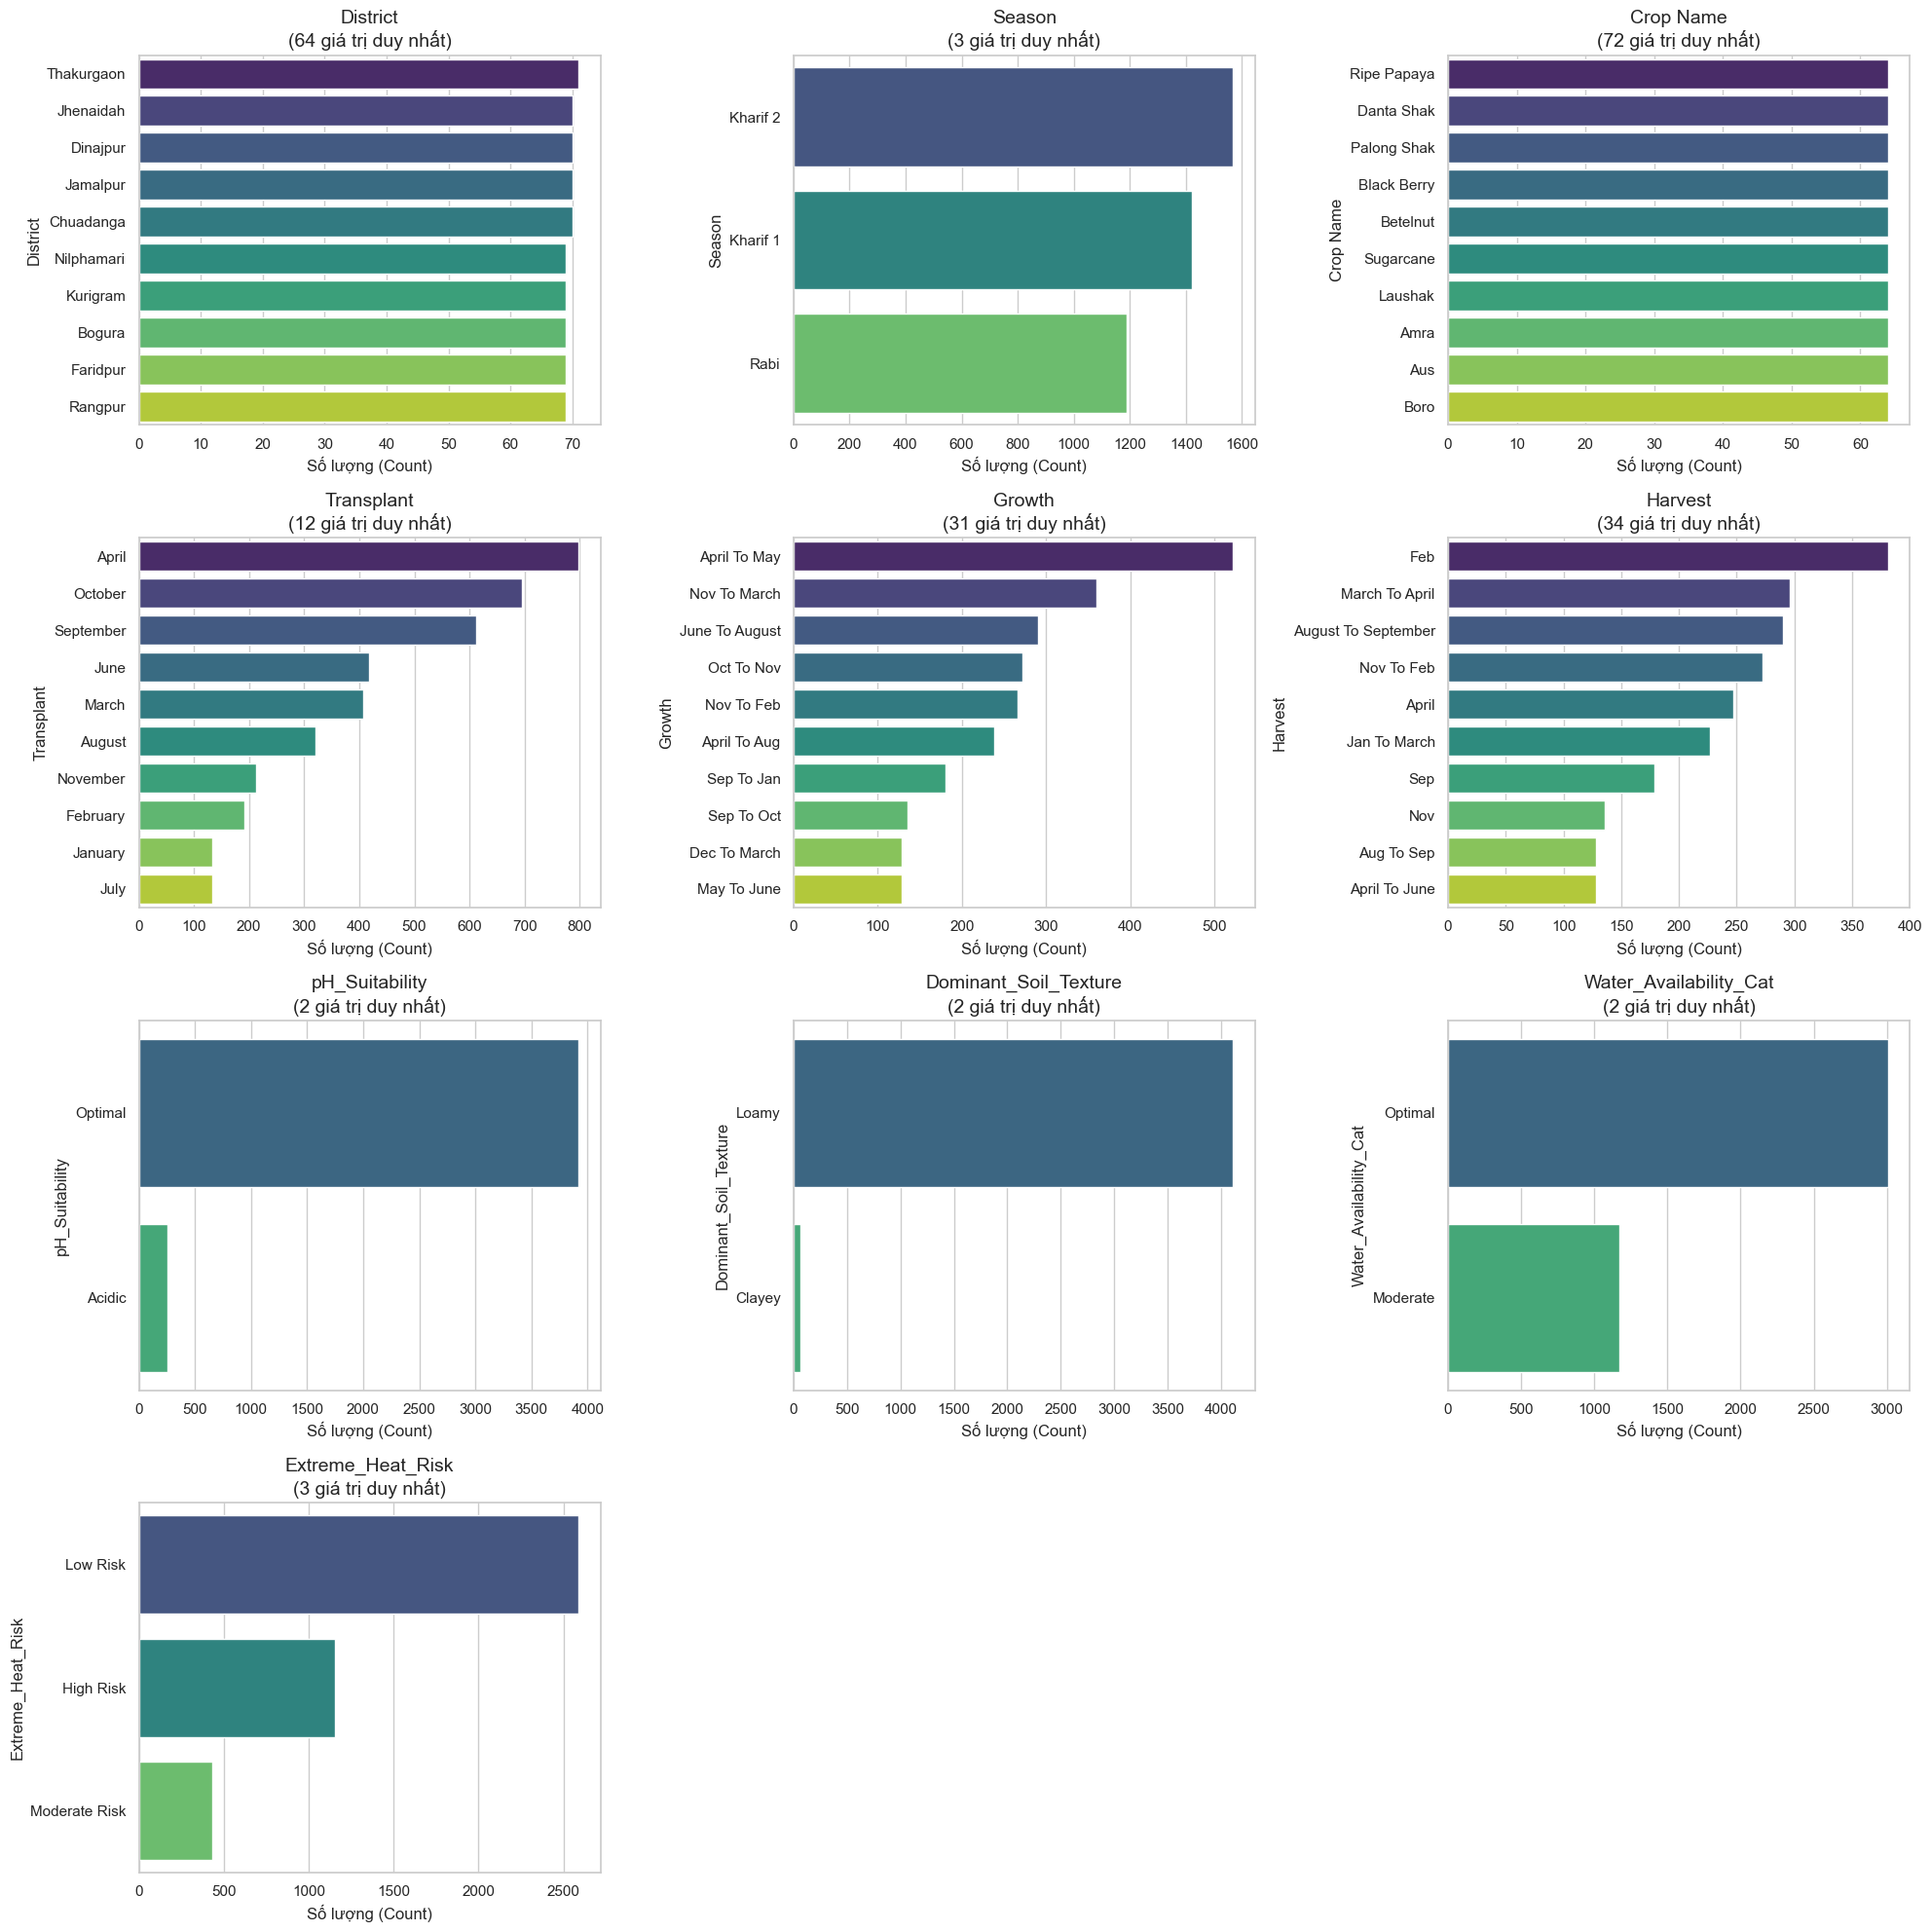


--- TÓM TẮT ĐẶC ĐIỂM BIẾN CHỮ ---
                        Số lượng nhãn (Unique) Nhãn phổ biến nhất  \
District                                    64         Thakurgaon   
Season                                       3           Kharif 2   
Crop Name                                   72               Aman   
Transplant                                  12              April   
Growth                                      31       April To May   
Harvest                                     34                Feb   
pH_Suitability                               2            Optimal   
Dominant_Soil_Texture                        2              Loamy   
Water_Availability_Cat                       2            Optimal   
Extreme_Heat_Risk                            3           Low Risk   

                        Tần suất nhãn phổ biến nhất  Tỷ lệ nhãn phổ biến (%)  
District                                         71                     1.70  
Season                                         

In [10]:
import math

# ==========================================
# CHỈ SỐ 5 & 6: SKEWNESS, STD & BIỂU ĐỒ PHÂN PHỐI (TẤT CẢ CỘT SỐ)
# ==========================================

# 1. Báo cáo bảng số liệu đầy đủ cho tất cả cột số
stats_df = pd.DataFrame({
    'Kiểu dữ liệu': df[numeric_predictors].dtypes,
    'Độ lệch chuẩn (Std Dev)': df[numeric_predictors].std(),
    'Độ lệch (Skewness)': df[numeric_predictors].skew(),
    'Giá trị Min': df[numeric_predictors].min(),
    'Giá trị Max': df[numeric_predictors].max()
})

print("\n--- BÁO CÁO PHÂN PHỐI & PHƯƠNG SAI ĐẦY ĐỦ (Tất cả cột số) ---")
# Hiển thị toàn bộ các dòng trong dataframe
with pd.option_context('display.max_rows', None):
    print(stats_df.sort_values(by='Độ lệch (Skewness)', ascending=False))

# 2. Vẽ biểu đồ Histogram cho TẤT CẢ các cột số
n_num_features = len(numeric_predictors)
num_cols_grid = 4
num_rows_grid = math.ceil(n_num_features / num_cols_grid)

plt.figure(figsize=(20, num_rows_grid * 4))

for i, col in enumerate(numeric_predictors, 1):
    plt.subplot(num_rows_grid, num_cols_grid, i)
    # Vẽ phân phối
    sns.histplot(df[col], kde=True, color='teal', bins=30)
    
    sk = df[col].skew()
    plt.title(f'{col}\nSkewness: {sk:.2f}', fontsize=12)
    
    # Nếu lệch quá nặng (abs > 1), đổi màu tiêu đề thành đỏ để cảnh báo
    if abs(sk) > 1:
        plt.gca().title.set_color('red')

plt.tight_layout()
plt.show()

# ==========================================
# PHÂN TÍCH TOÀN BỘ BIẾN CHỮ (CATEGORICAL)
# ==========================================
print("\n--- PHÂN TÍCH CHI TIẾT BIẾN PHÂN LOẠI (CATEGORICAL) ---")

n_cat = len(categorical_cols)
if n_cat > 0:
    cat_cols_grid = 3
    cat_rows_grid = math.ceil(n_cat / cat_cols_grid)
    
    plt.figure(figsize=(20, cat_rows_grid * 5))

    for i, col in enumerate(categorical_cols, 1):
        plt.subplot(cat_rows_grid, cat_cols_grid, i)
        
        # Lấy top 10 giá trị xuất hiện nhiều nhất để biểu đồ không bị quá tải
        top_n = df[col].value_counts().head(10)
        sns.barplot(x=top_n.values, y=top_n.index, palette='viridis')
        
        plt.title(f"{col}\n({df[col].nunique()} giá trị duy nhất)", fontsize=14)
        plt.xlabel("Số lượng (Count)")

    plt.tight_layout()
    plt.show()

    # In bảng tóm tắt Cardinality cho tất cả biến chữ
    cat_summary = pd.DataFrame({
        'Số lượng nhãn (Unique)': [df[c].nunique() for c in categorical_cols],
        'Nhãn phổ biến nhất': [df[c].mode()[0] for c in categorical_cols],
        'Tần suất nhãn phổ biến nhất': [df[c].value_counts().iloc[0] for c in categorical_cols],
        'Tỷ lệ nhãn phổ biến (%)': [(df[c].value_counts().iloc[0] / len(df) * 100).round(2) for c in categorical_cols]
    }, index=categorical_cols)
    
    print("\n--- TÓM TẮT ĐẶC ĐIỂM BIẾN CHỮ ---")
    print(cat_summary)